# Exploratory Data Analysis — NHANES Diabetes Dataset

This notebook performs exploratory data analysis on the analysis-ready NHANES dataset produced by `01_data_merging.ipynb`. The goal is to understand the structure of the data, identify missing values, examine the distribution of predictors, and inspect the relationship between predictors and the diabetes outcome before modelling.

**Input:** `data/processed/nhanes_diabetes_analysis_ready.parquet`

**Sections:**
1. Dataset overview
2. Target variable: class distribution
3. Missing values
4. Distributions of continuous predictors
5. Distributions of categorical predictors
6. Predictor vs. outcome relationships
7. Correlation analysis
8. Survey cycle distribution

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

In [5]:
df = pd.read_parquet("../data/raw/nhanes_diabetes_raw.parquet")

print(f"Shape: {df.shape}")
df.head()

Shape: (26001, 31)


,participant_id,cycle,diabetes,age,sex,race_ethnicity,education_level,income_poverty_ratio,bmi,waist_circumference,...,hdl_cholesterol_mg_dl,triglycerides_mg_dl,ldl_cholesterol_mg_dl,energy_kcal,protein_g,carbohydrate_g,total_sugar_g,fiber_g,total_fat_g,cholesterol_mg
0,62161.0,2011-2012,0,22.0,1.0,3.0,3.0,3.15,23.3,81.0,...,41.0,84.0,110.0,2969.0,104.68,359.59,109.09,18.6,123.81,328.0
1,62164.0,2011-2012,0,44.0,2.0,3.0,4.0,1.67,23.2,80.1,...,28.0,56.0,151.0,1115.0,73.13,91.67,32.29,9.5,51.54,207.0
2,62169.0,2011-2012,0,21.0,1.0,6.0,3.0,0.33,20.1,69.6,...,43.0,78.0,73.0,1831.0,77.46,297.51,78.19,4.3,34.61,205.0
3,62172.0,2011-2012,0,43.0,2.0,4.0,3.0,2.02,33.3,120.4,...,73.0,141.0,68.0,1845.0,57.43,192.82,58.56,2.8,42.02,160.0
4,62174.0,2011-2012,0,80.0,1.0,3.0,5.0,4.30,33.9,116.5,...,54.0,NaN,NaN,1178.0,39.35,146.72,84.63,12.0,49.75,468.0


## 1. Dataset Overview

Basic information about the dataset: number of rows, columns, data types, and a summary of descriptive statistics.

In [6]:
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()
print(df.dtypes)

Rows:    26,001
Columns: 31

participant_id                      float64
cycle                                object
diabetes                              Int64
age                                 float64
sex                                 float64
race_ethnicity                      float64
education_level                     float64
income_poverty_ratio                float64
bmi                                 float64
waist_circumference                 float64
mean_systolic_bp                    float64
mean_diastolic_bp                   float64
ever_smoked_100_cigarettes          float64
average_alcoholic_drinks_per_day    float64
vigorous_work_activity              float64
moderate_work_activity              float64
walk_or_bicycle_transport           float64
vigorous_recreational_activity      float64
moderate_recreational_activity      float64
sleep_hours                         float64
total_cholesterol_mg_dl             float64
hdl_cholesterol_mg_dl               float64
tri

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
participant_id,26001.0,NaN,NaN,NaN,91891.363601,20151.54102,62161.0,75404.0,86820.0,113765.0,124822.0
cycle,26001,4,2017-March 2020,9145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diabetes,26001.0,<NA>,<NA>,<NA>,0.1888,0.391358,0.0,0.0,0.0,0.0,1.0
age,26001.0,NaN,NaN,NaN,50.106573,17.691884,20.0,35.0,50.0,64.0,80.0
sex,26001.0,NaN,NaN,NaN,1.510634,0.499897,1.0,1.0,2.0,2.0,2.0
race_ethnicity,26001.0,NaN,NaN,NaN,3.398177,1.552376,1.0,3.0,3.0,4.0,7.0
education_level,26001.0,NaN,NaN,NaN,3.500365,1.257963,1.0,3.0,4.0,4.0,9.0
income_poverty_ratio,23038.0,NaN,NaN,NaN,2.499933,1.636948,0.0,1.08,2.07,4.07,5.0
bmi,24268.0,NaN,NaN,NaN,29.444037,7.238778,13.4,24.4,28.2,33.0,92.3
waist_circumference,23168.0,NaN,NaN,NaN,99.838583,16.763268,55.5,87.9,98.4,109.7,187.5


## 2. Target Variable: Class Distribution

The `diabetes` column is the binary outcome variable. We inspect the class balance here, since class imbalance directly influences the choice of preprocessing strategy (SMOTE vs. undersampling).

Counts:
diabetes
0    21092
1     4909
Name: count, dtype: Int64

Proportions:
diabetes
0    0.8112
1    0.1888
Name: proportion, dtype: Float64


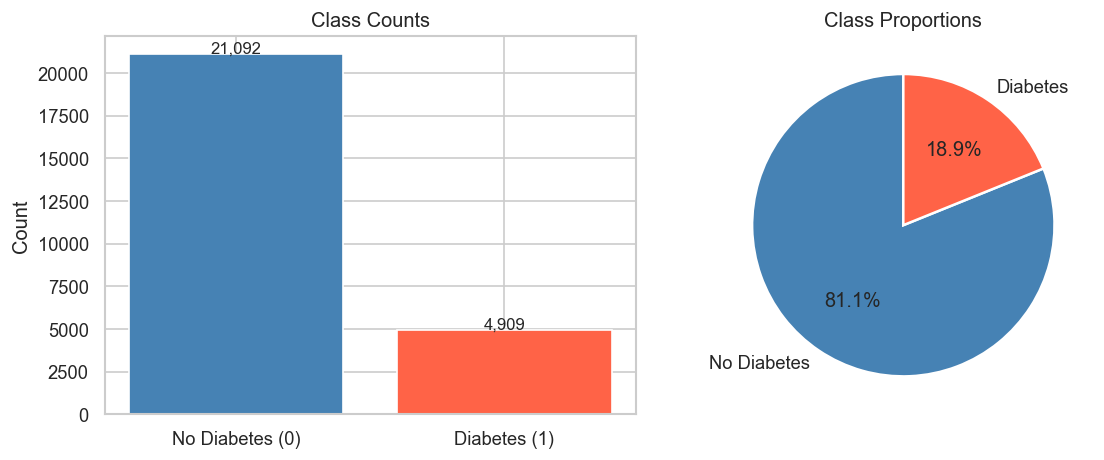

In [8]:
counts = df["diabetes"].value_counts()
proportions = df["diabetes"].value_counts(normalize=True)

print("Counts:")
print(counts)
print()
print("Proportions:")
print(proportions.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["No Diabetes (0)", "Diabetes (1)"], counts, color=["steelblue", "tomato"], edgecolor="white")
axes[0].set_title("Class Counts")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontsize=10)

axes[1].pie(
    proportions,
    labels=["No Diabetes", "Diabetes"],
    autopct="%1.1f%%",
    colors=["steelblue", "tomato"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Class Proportions")

plt.tight_layout()
plt.show()

## 3. Missing Values

Missing values are common in NHANES data, because not all participants complete all components. We inspect missingness per column to understand which variables have substantial gaps and may need imputation or special handling during preprocessing.

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

missing_df = missing_df[missing_df["missing_count"] > 0]
print(missing_df.to_string())

                                  missing_count  missing_pct
ldl_cholesterol_mg_dl                     15069        57.96
triglycerides_mg_dl                       14928        57.41
average_alcoholic_drinks_per_day          10667        41.03
cholesterol_mg                             3680        14.15
energy_kcal                                3680        14.15
total_fat_g                                3680        14.15
fiber_g                                    3680        14.15
total_sugar_g                              3680        14.15
carbohydrate_g                             3680        14.15
protein_g                                  3680        14.15
income_poverty_ratio                       2963        11.40
hdl_cholesterol_mg_dl                      2915        11.21
total_cholesterol_mg_dl                    2915        11.21
waist_circumference                        2833        10.90
mean_diastolic_bp                          2832        10.89
mean_systolic_bp        

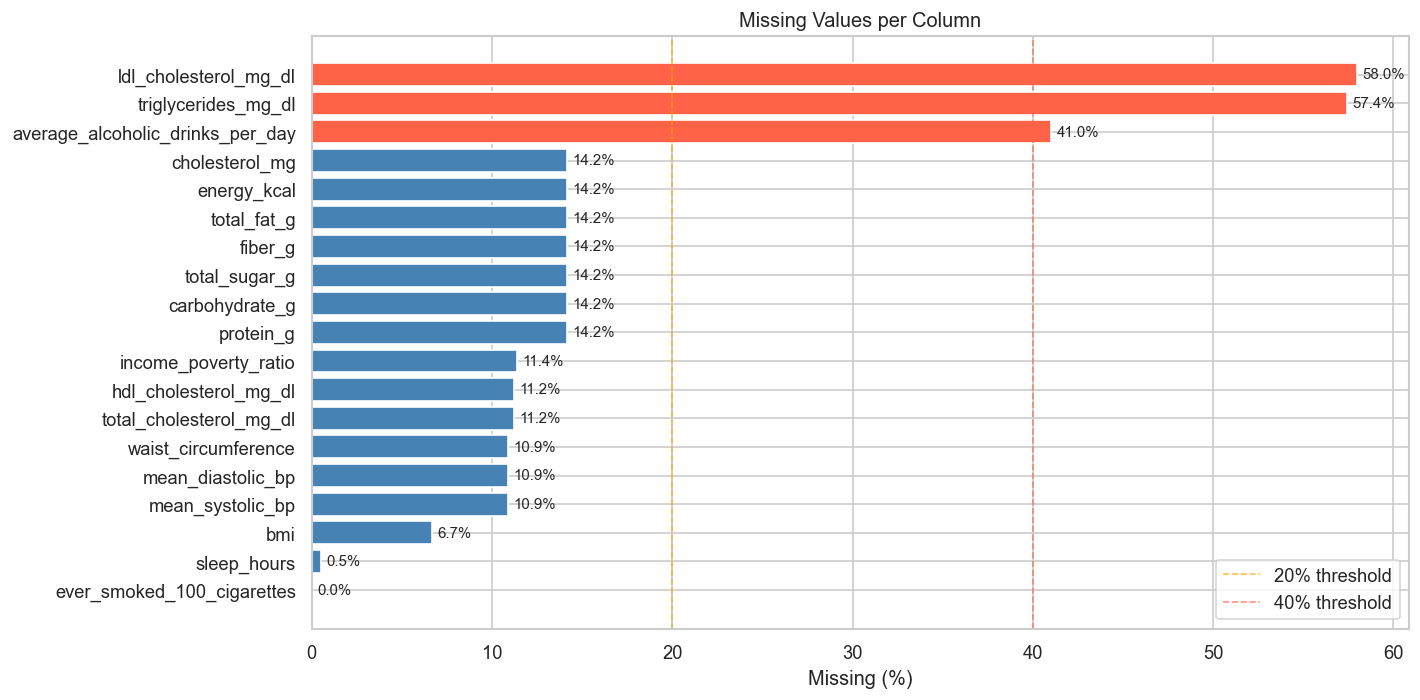

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["tomato" if p > 40 else "orange" if p > 20 else "steelblue" for p in missing_df["missing_pct"]]
bars = ax.barh(missing_df.index, missing_df["missing_pct"], color=colors, edgecolor="white")

ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values per Column")
ax.axvline(20, color="orange", linestyle="--", linewidth=1, alpha=0.7, label="20% threshold")
ax.axvline(40, color="tomato", linestyle="--", linewidth=1, alpha=0.7, label="40% threshold")
ax.legend()
ax.invert_yaxis()

for bar, pct in zip(bars, missing_df["missing_pct"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 4. Distributions of Continuous Predictors

We inspect the distribution of all continuous predictor variables using histograms with a KDE overlay. This helps identify skewed distributions, outliers, and any variables that may benefit from log-transformation or capping during preprocessing.

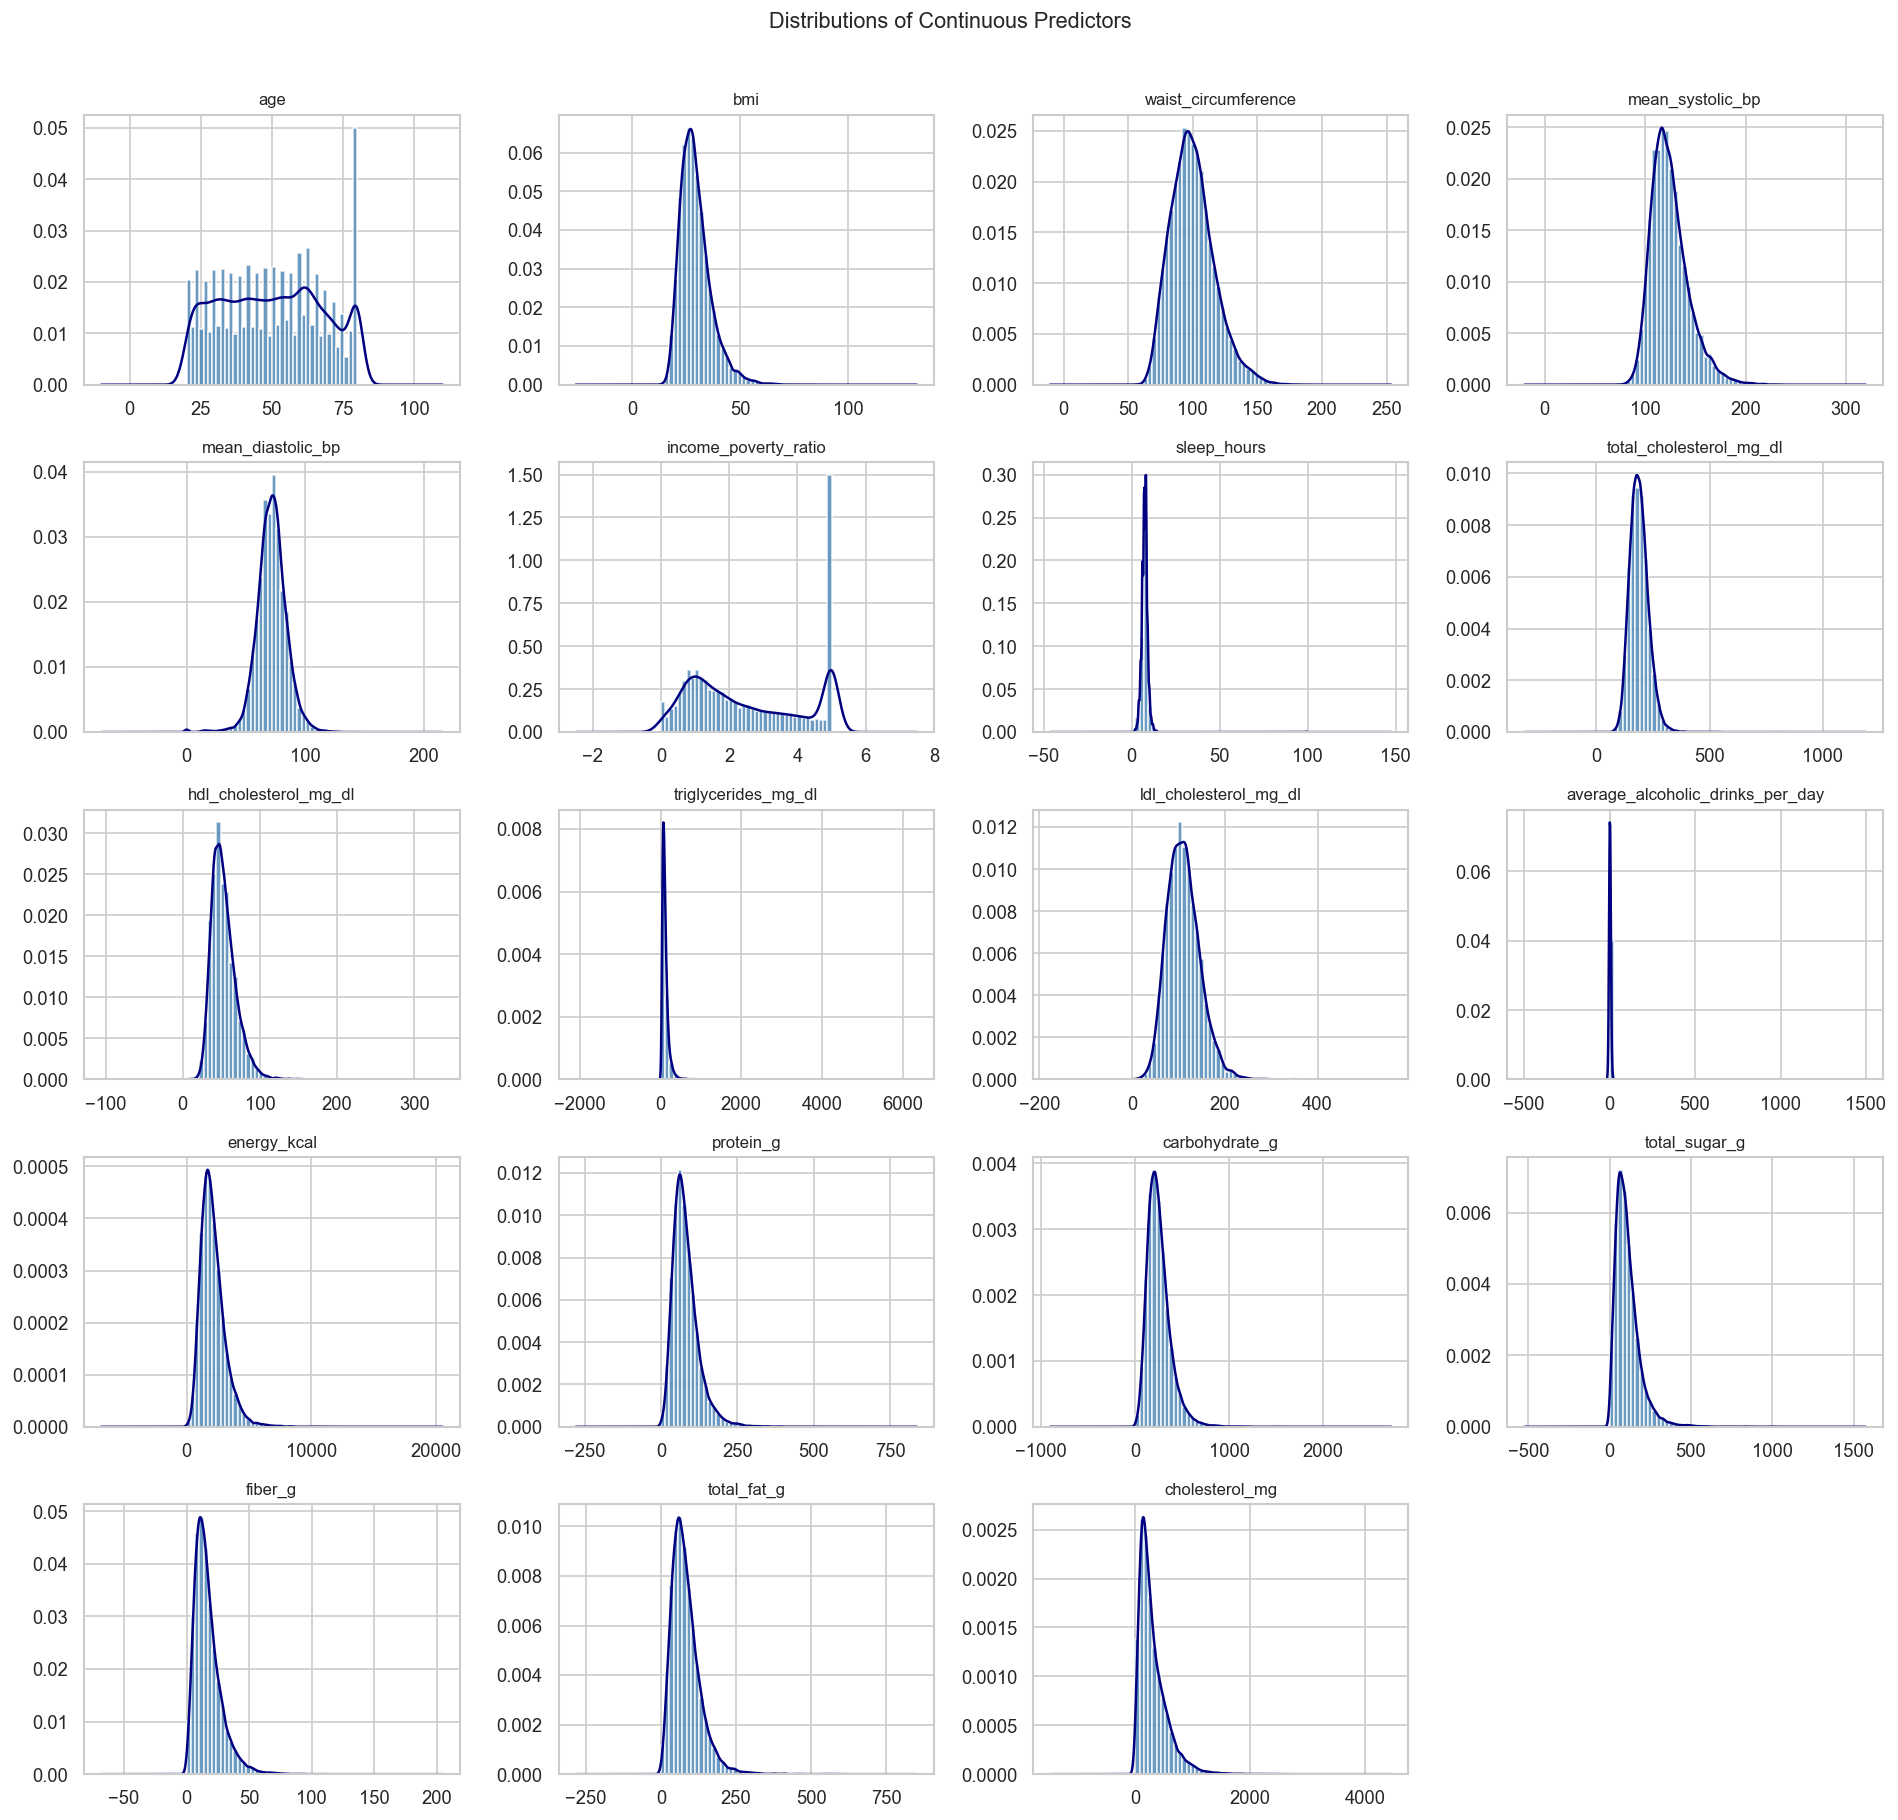

In [11]:
continuous_cols = [
    "age", "bmi", "waist_circumference",
    "mean_systolic_bp", "mean_diastolic_bp",
    "income_poverty_ratio", "sleep_hours",
    "total_cholesterol_mg_dl", "hdl_cholesterol_mg_dl",
    "triglycerides_mg_dl", "ldl_cholesterol_mg_dl",
    "average_alcoholic_drinks_per_day",
    "energy_kcal", "protein_g", "carbohydrate_g",
    "total_sugar_g", "fiber_g", "total_fat_g", "cholesterol_mg"
]

# Only keep columns that exist in the dataframe
continuous_cols = [c for c in continuous_cols if c in df.columns]

n_cols = 4
n_rows = -(-len(continuous_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color="steelblue", edgecolor="white", alpha=0.8, density=True)
    data.plot.kde(ax=axes[i], color="navy", linewidth=1.5)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions of Continuous Predictors", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Distributions of Categorical Predictors

Categorical predictors are encoded as numeric codes in the NHANES dataset. We inspect the frequency distribution of each category to identify rare categories, unexpected codes (e.g. 7 = Refused, 9 = Don't know), and overall balance between groups.

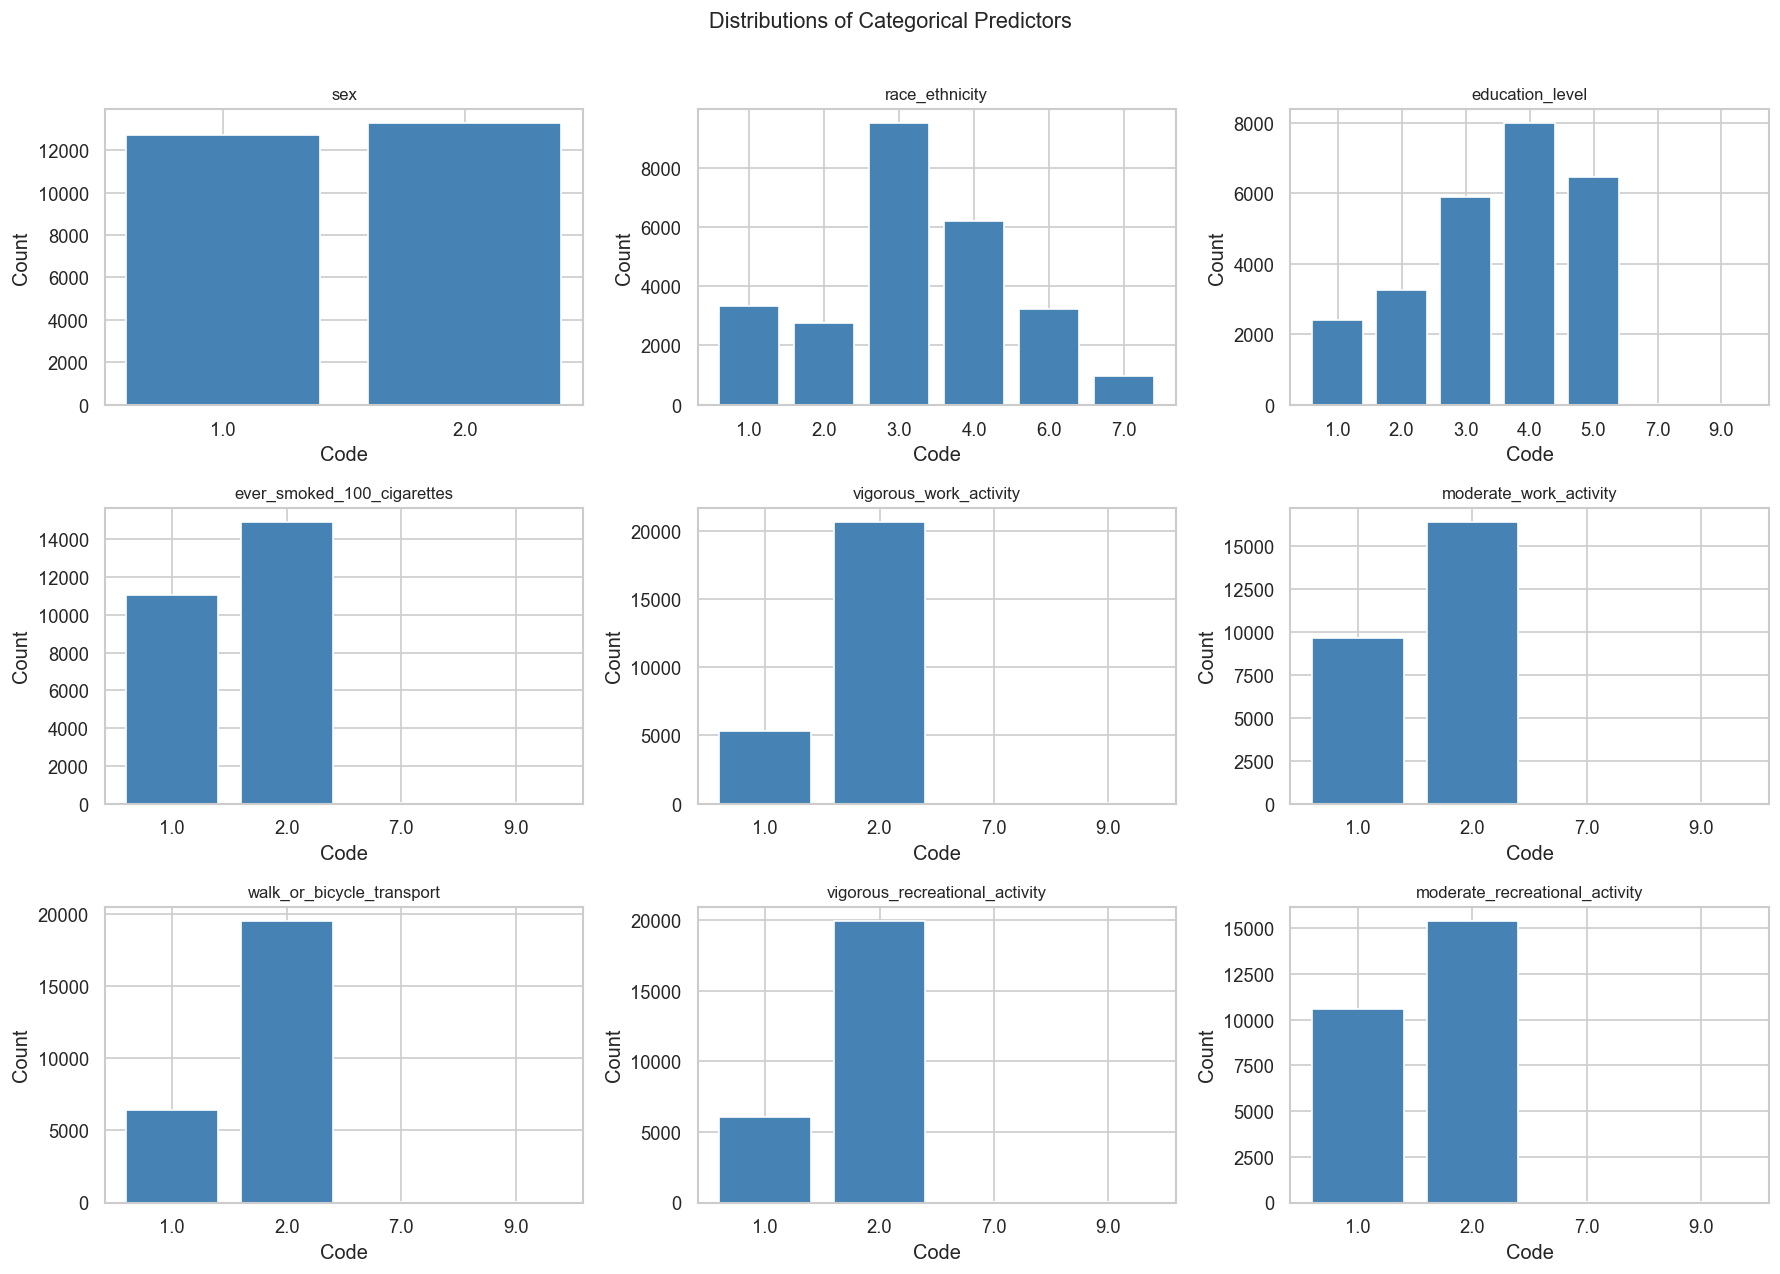

In [12]:
categorical_cols = [
    "sex", "race_ethnicity", "education_level",
    "ever_smoked_100_cigarettes",
    "vigorous_work_activity", "moderate_work_activity",
    "walk_or_bicycle_transport",
    "vigorous_recreational_activity", "moderate_recreational_activity"
]

categorical_cols = [c for c in categorical_cols if c in df.columns]

n_cols = 3
n_rows = -(-len(categorical_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Code")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions of Categorical Predictors", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Predictor vs. Outcome Relationships

Here we compare the distribution of each continuous predictor between the diabetic and non-diabetic groups. Box plots make it easy to spot which variables show meaningful separation between the two classes, which informs feature importance expectations.

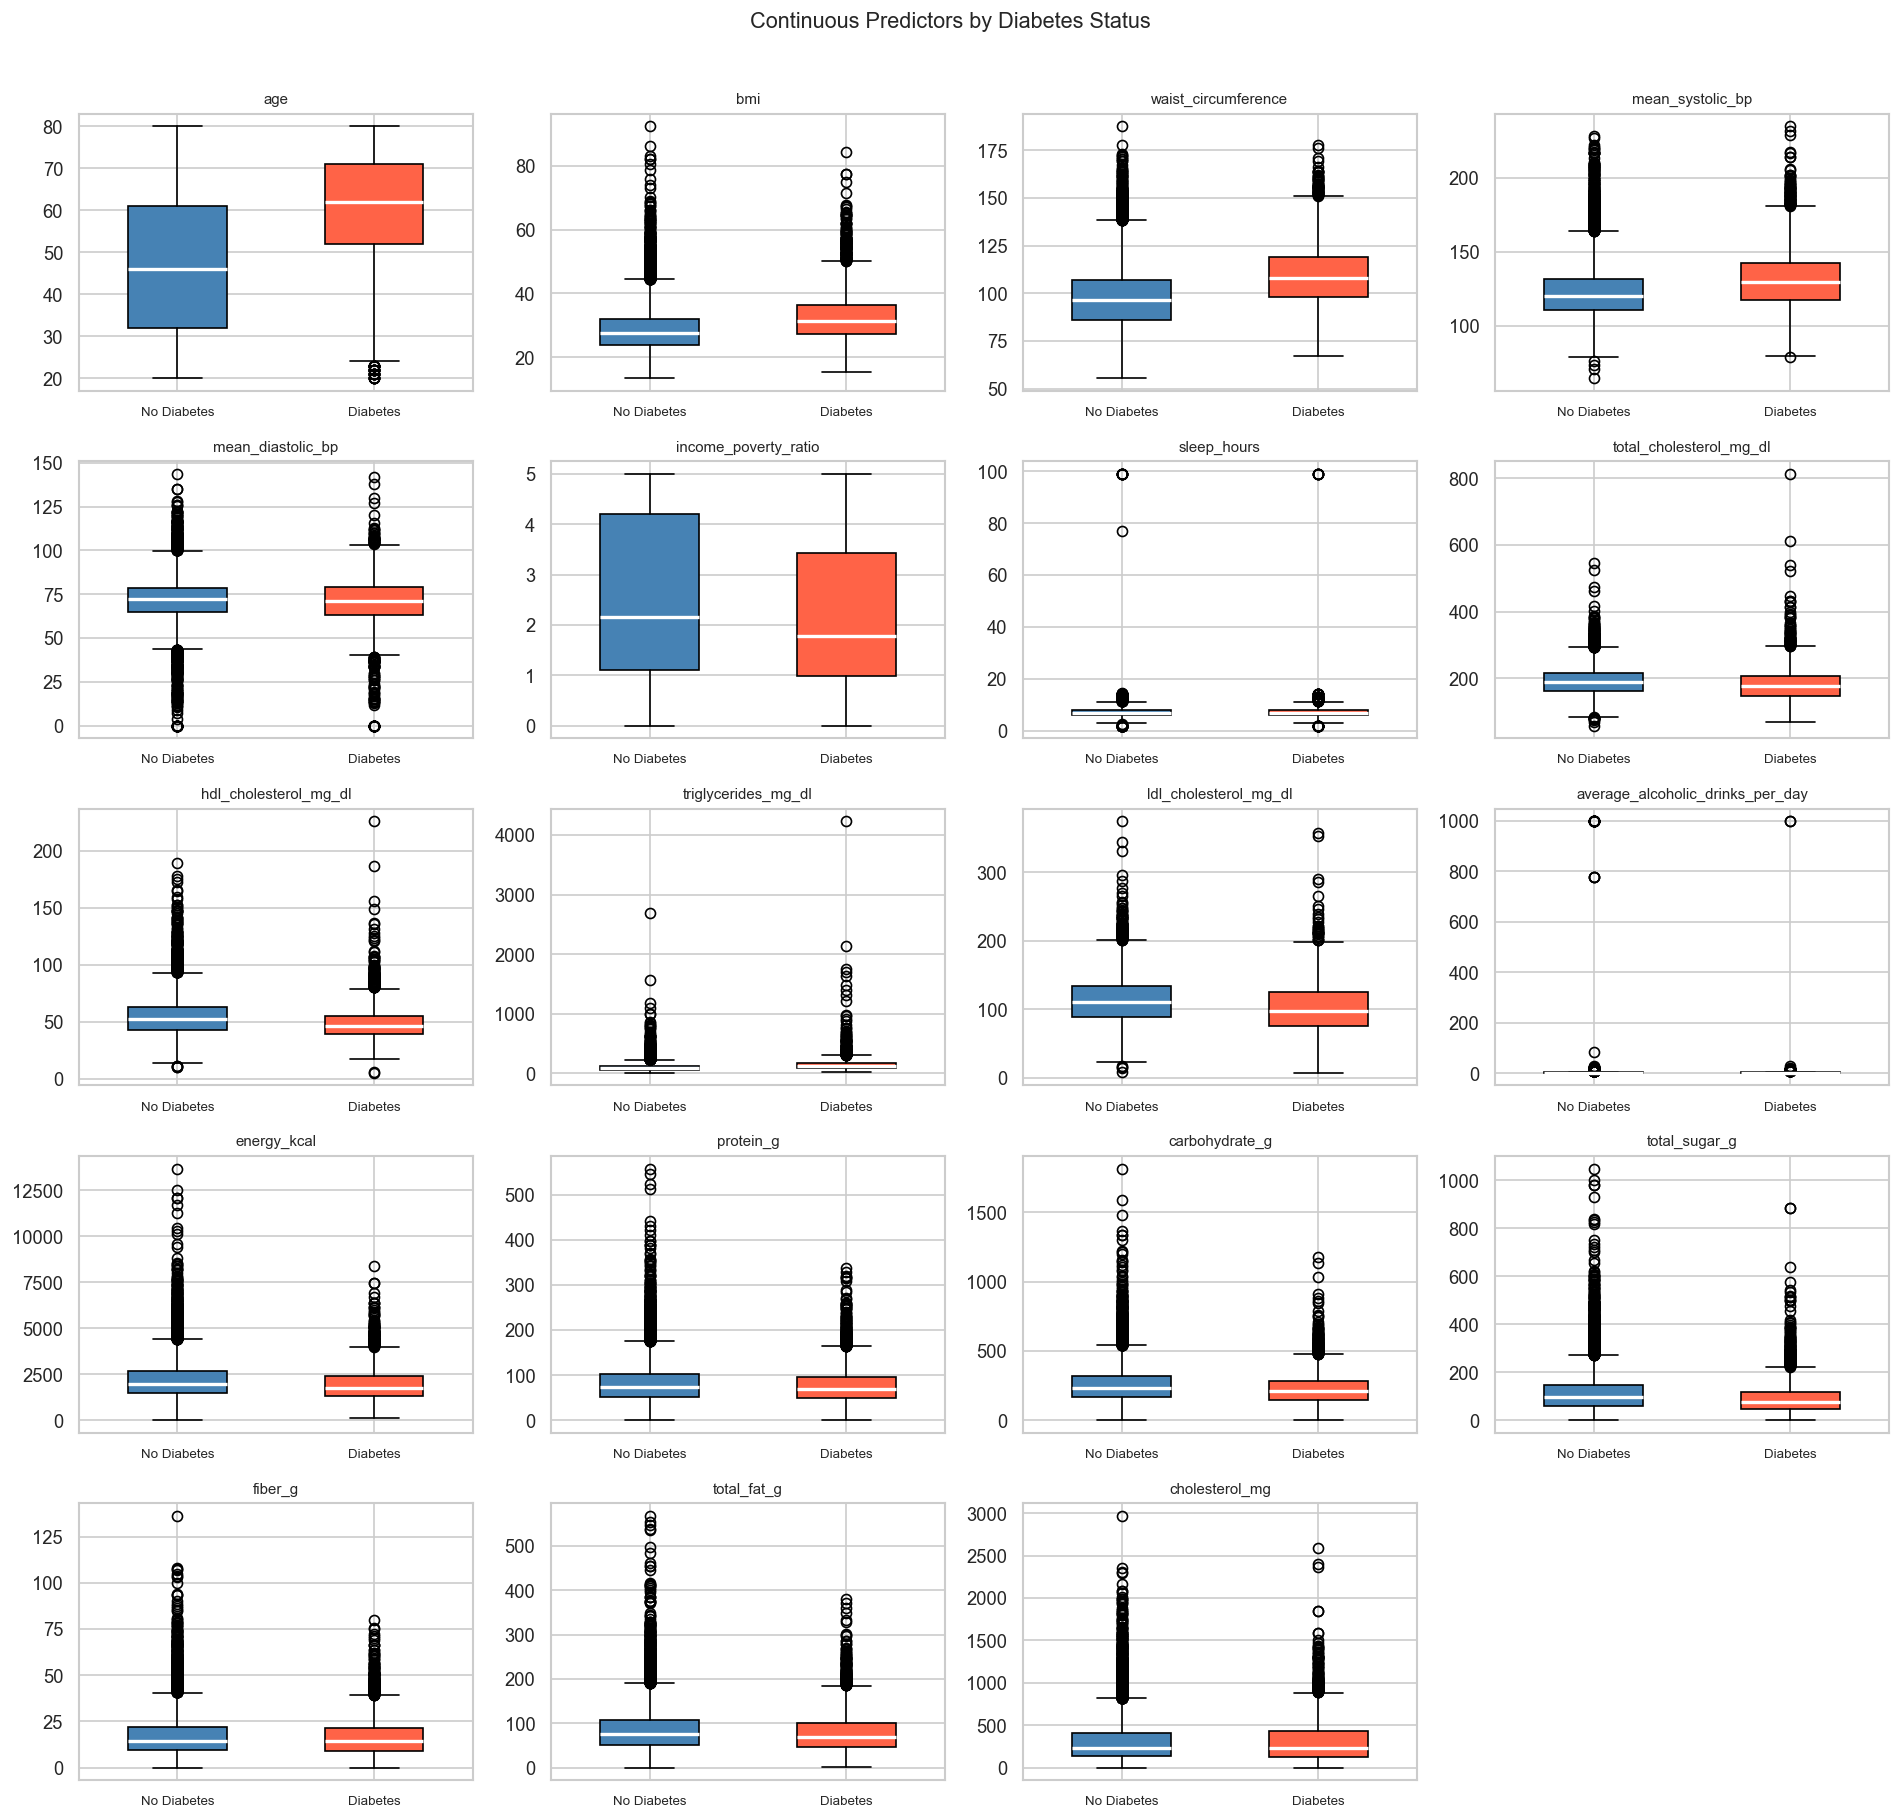

In [ ]:
n_cols = 4
n_rows = -(-len(continuous_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    groups = [df.loc[df["diabetes"] == 0, col].dropna(),
            df.loc[df["diabetes"] == 1, col].dropna()]
    bp = axes[i].boxplot(groups, tick_labels=["No Diabetes", "Diabetes"],
                        patch_artist=True, widths=0.5,
                        medianprops={"color": "white", "linewidth": 2})
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][1].set_facecolor("tomato")
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="x", labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Continuous Predictors by Diabetes Status", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

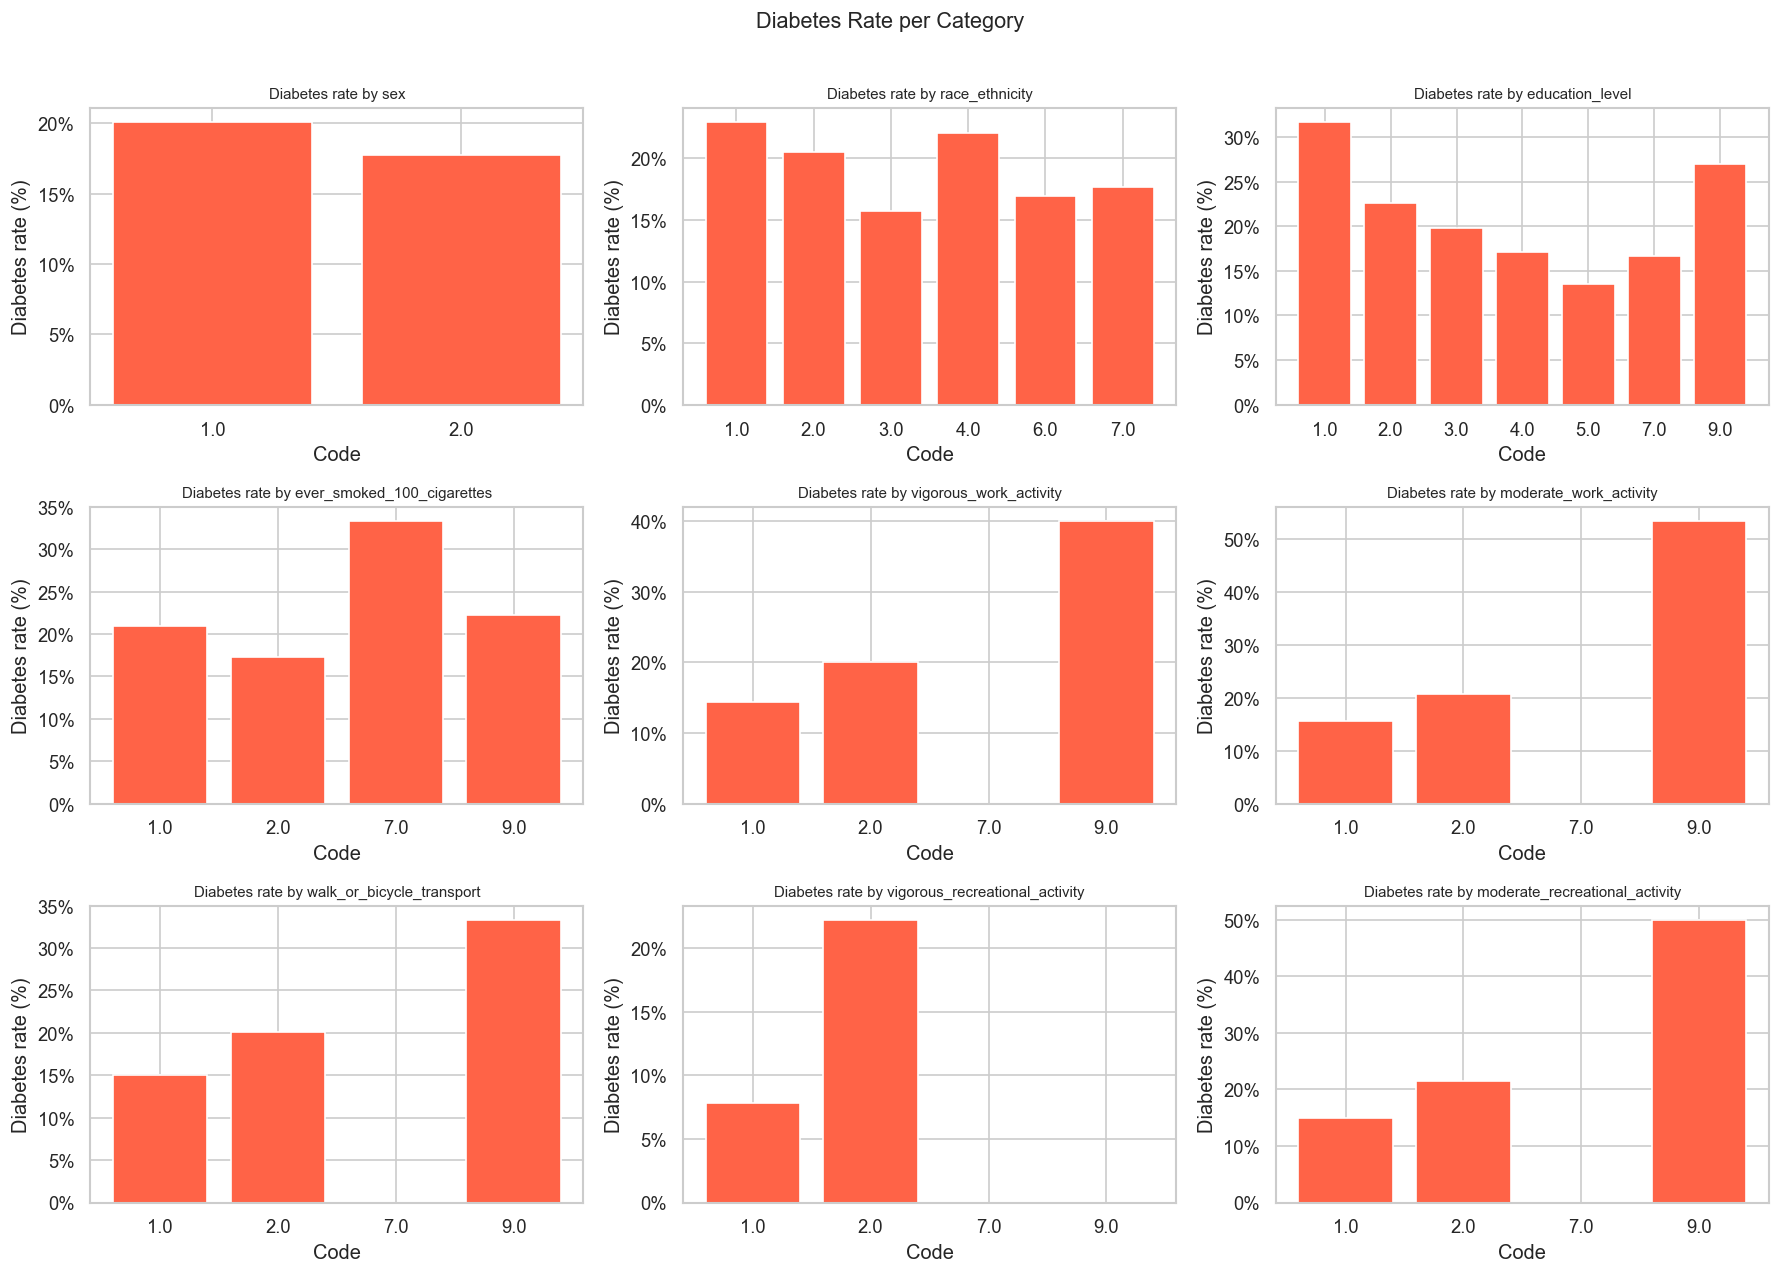

In [14]:
# Diabetes rate per category for categorical predictors
n_cols = 3
n_rows = -(-len(categorical_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    rate = df.groupby(col)["diabetes"].mean().sort_index()
    axes[i].bar(rate.index.astype(str), rate.values * 100, color="tomato", edgecolor="white")
    axes[i].set_title(f"Diabetes rate by {col}", fontsize=9)
    axes[i].set_xlabel("Code")
    axes[i].set_ylabel("Diabetes rate (%)")
    axes[i].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Diabetes Rate per Category", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

A correlation heatmap of all continuous predictors and the diabetes outcome. High inter-predictor correlations may indicate multicollinearity, which can affect some model types. The correlation with the `diabetes` column shows which predictors have the strongest linear relationship with the outcome.

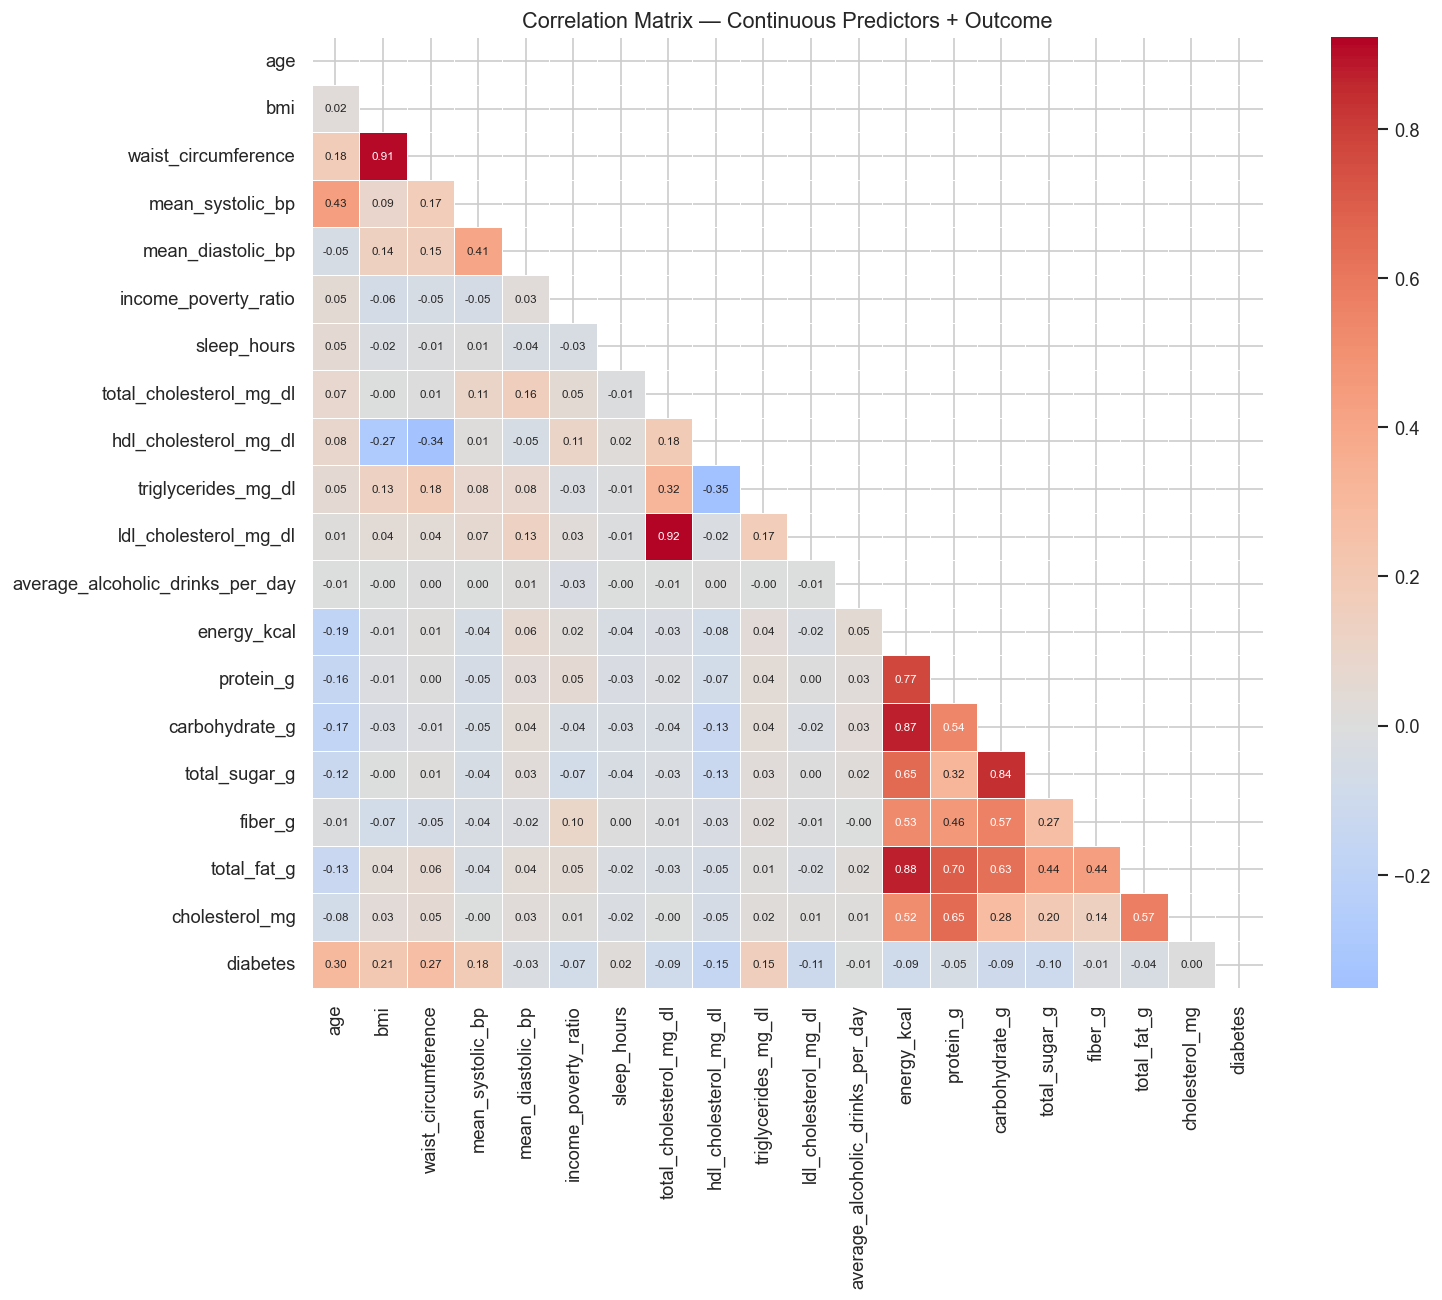

In [15]:
corr_cols = continuous_cols + ["diabetes"]
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 7}
)

ax.set_title("Correlation Matrix — Continuous Predictors + Outcome", fontsize=13)
plt.tight_layout()
plt.show()

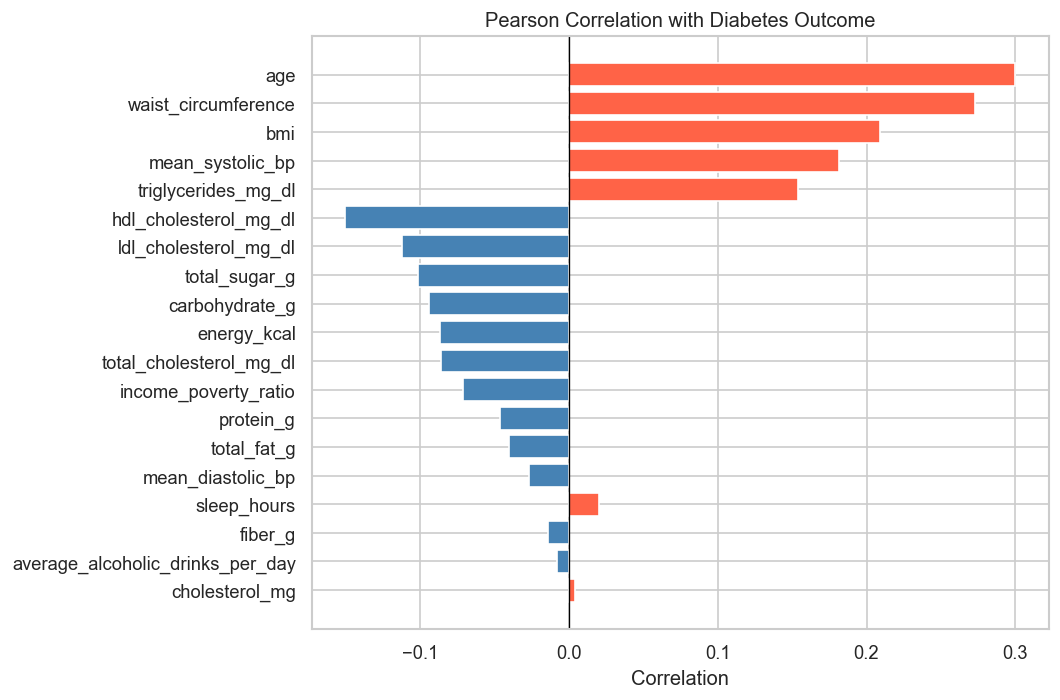

In [16]:
# Top correlations with diabetes outcome
diabetes_corr = corr_matrix["diabetes"].drop("diabetes").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["tomato" if v > 0 else "steelblue" for v in diabetes_corr]
ax.barh(diabetes_corr.index, diabetes_corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with Diabetes Outcome")
ax.set_xlabel("Correlation")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Survey Cycle Distribution

We inspect how many participants come from each NHANES survey cycle and whether the diabetes prevalence differs across cycles. This can reveal temporal trends or differences in data collection that should be kept in mind during modelling.

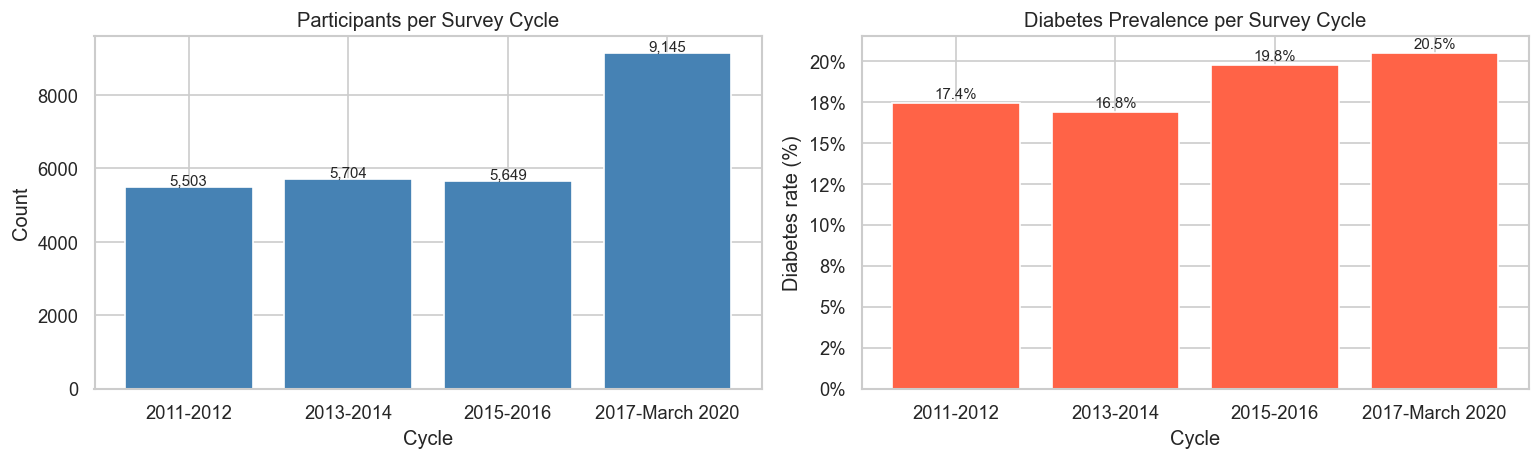

In [17]:
cycle_counts = df["cycle"].value_counts().sort_index()
cycle_diabetes_rate = df.groupby("cycle")["diabetes"].mean().sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(cycle_counts.index, cycle_counts.values, color="steelblue", edgecolor="white")
axes[0].set_title("Participants per Survey Cycle")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Cycle")
for i, v in enumerate(cycle_counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=9)

axes[1].bar(cycle_diabetes_rate.index, cycle_diabetes_rate.values, color="tomato", edgecolor="white")
axes[1].set_title("Diabetes Prevalence per Survey Cycle")
axes[1].set_ylabel("Diabetes rate (%)")
axes[1].set_xlabel("Cycle")
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for i, v in enumerate(cycle_diabetes_rate.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Summary

Key takeaways from the EDA to inform preprocessing and modelling decisions:

- **Class imbalance**: The dataset is imbalanced (~19% diabetes). SMOTE or undersampling is needed.
- **Missing values**: Several variables have substantial missingness (notably fasting glucose and lipid variables). Imputation strategy should be defined in the preprocessing notebook.
- **Skewed distributions**: Variables like triglycerides, alcohol consumption, and dietary variables are right-skewed. Log-transformation may help linear models.
- **Categorical codes**: Some categorical variables may contain NHANES refusal/don't-know codes (7, 9, 99) that should be recoded as missing during preprocessing.
- **Strongest predictors**: Age, BMI, and waist circumference show the clearest separation between diabetic and non-diabetic groups.